# EDA and Feature Engineering Pipeline for NeuroShield

This notebook explores the diabetic dataset, analyzes missing values, creates visualizations, and then runs the cleaning and feature engineering pipeline step by step.


In [29]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Load the raw data
df_raw = pd.read_csv('data/diabetic/diabetic_data.csv')
print(f"Raw dataset shape: {df_raw.shape}")


Raw dataset shape: (101766, 50)


In [30]:
# Basic exploration
print("=== First 5 rows ===")
display(df_raw.head())

print("\n=== Dataset info ===")
df_raw.info()

print("\n=== Summary statistics (numeric columns) ===")
display(df_raw.describe())

print("\n=== Summary statistics (categorical columns) ===")
categorical_cols = df_raw.select_dtypes(include=['object']).columns
display(df_raw[categorical_cols].describe())


=== First 5 rows ===


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO



=== Dataset info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000



=== Summary statistics (categorical columns) ===


,race,gender,age,weight,payer_code,medical_specialty,diag_1,diag_2,diag_3,max_glu_serum,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
count,101766,101766,101766,101766,101766,101766,101766,101766,101766,5346,...,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766
unique,6,3,10,10,18,73,717,749,790,3,...,1,4,4,2,2,2,2,2,2,3
top,Caucasian,Female,[70-80),?,?,?,428,276,250,Norm,...,No,No,No,No,No,No,No,No,Yes,NO
freq,76099,54708,26068,98569,40256,49949,6862,6752,11555,2597,...,101766,47383,101060,101753,101765,101764,101765,54755,78363,54864


=== Missing values count ===


,Missing Count,Missing Percentage
max_glu_serum,96420,94.746772
A1Cresult,84748,83.277322



=== Count of '?' values (dataset's null marker) ===


,? Count,? Percentage
weight,98569,96.858479
medical_specialty,49949,49.082208
payer_code,40256,39.557416
race,2273,2.233555
diag_3,1423,1.398306
diag_2,358,0.351787
diag_1,21,0.020636


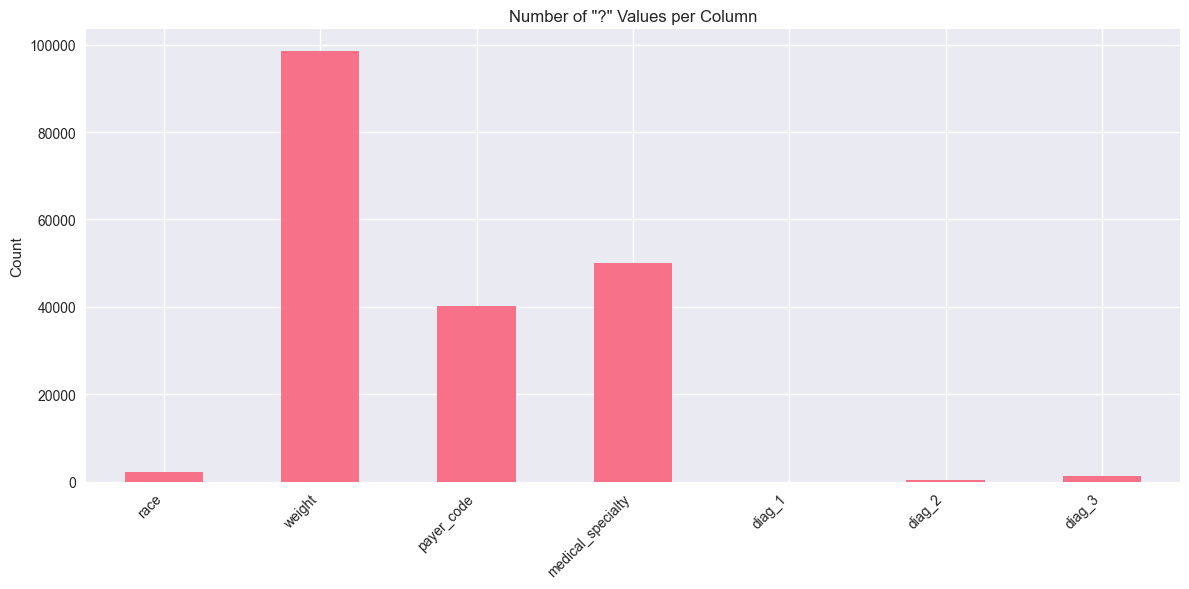

In [31]:
# Missing value analysis
print("=== Missing values count ===")
missing_count = df_raw.isnull().sum()
missing_percent = (missing_count / len(df_raw)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_count, 'Missing Percentage': missing_percent})
display(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False))

# Note: The dataset uses '?' as missing value marker, not NaN
print("\n=== Count of '?' values (dataset's null marker) ===")
question_mark_count = (df_raw == '?').sum()
question_mark_percent = (question_mark_count / len(df_raw)) * 100
question_mark_df = pd.DataFrame({'? Count': question_mark_count, '? Percentage': question_mark_percent})
display(question_mark_df[question_mark_df['? Count'] > 0].sort_values('? Count', ascending=False))

# Visualize missing values
plt.figure(figsize=(12, 6))
missing_to_plot = question_mark_df[question_mark_df['? Count'] > 0]
if len(missing_to_plot) > 0:
    missing_to_plot['? Count'].plot(kind='bar')
    plt.title('Number of "?" Values per Column')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No '?' values found.")


=== Visualizations ===


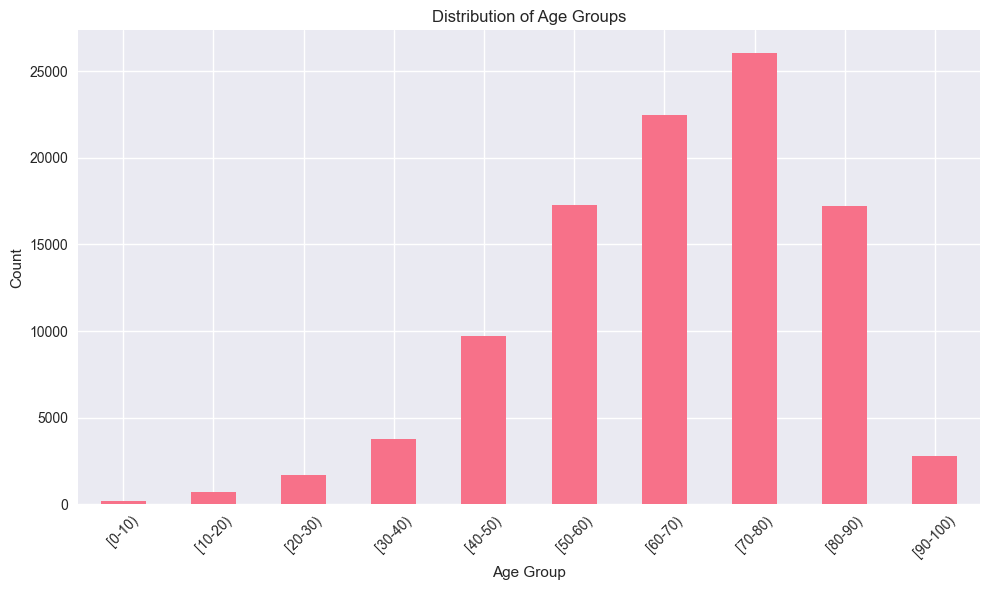

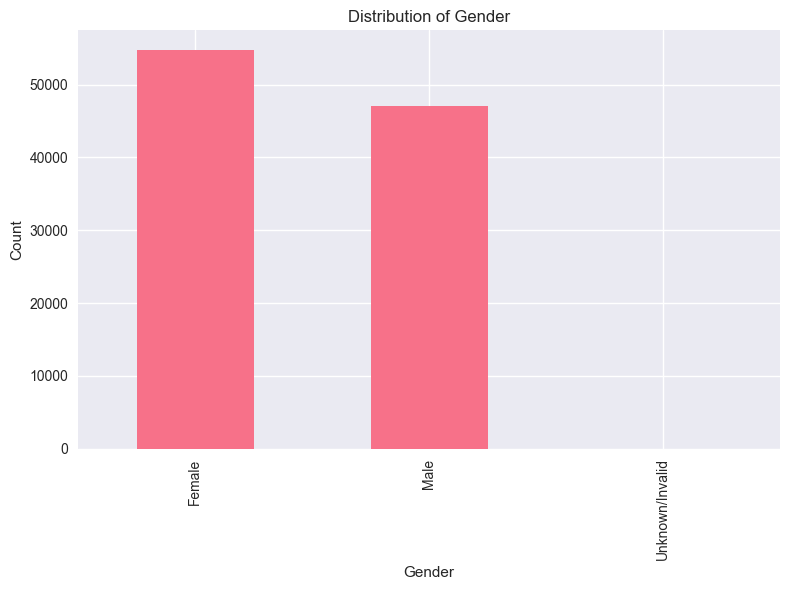

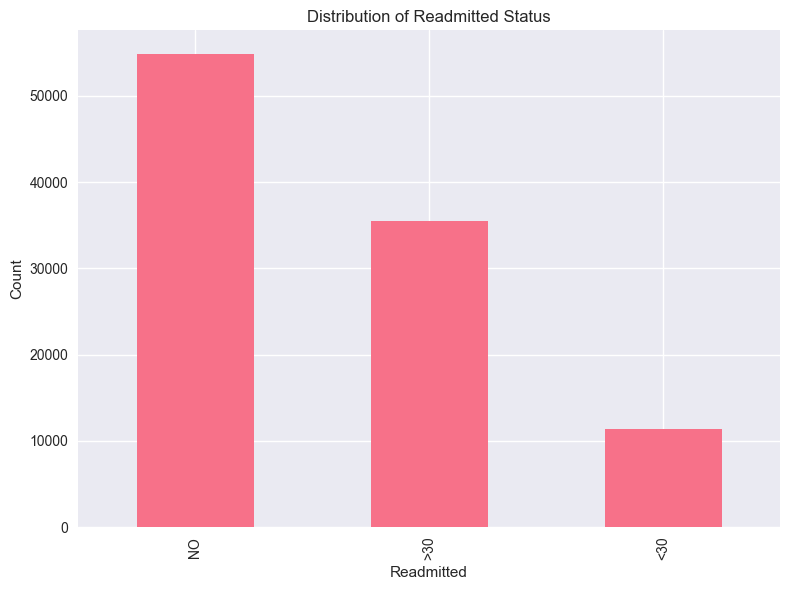

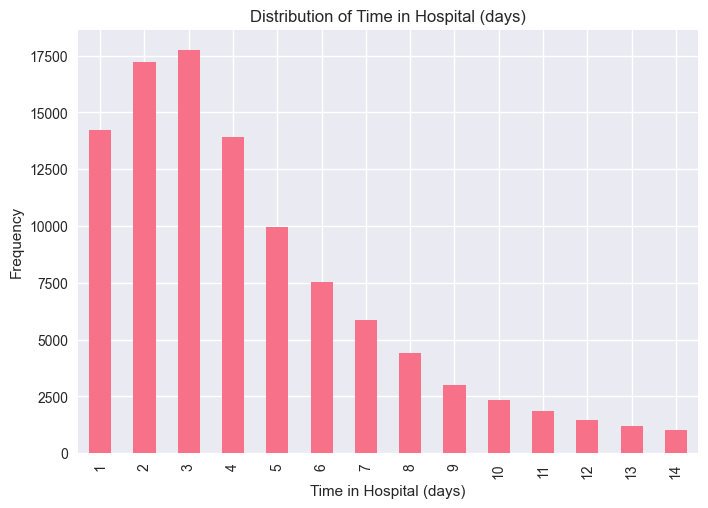

In [32]:
# Visualizations
print("=== Visualizations ===")

# 1. Age distribution (note: age is categorical)
plt.figure(figsize=(10, 6))
age_counts = df_raw['age'].value_counts().sort_index()
age_counts.plot(kind='bar')
plt.title('Distribution of Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Gender distribution
plt.figure(figsize=(8, 6))
gender_counts = df_raw['gender'].value_counts()
gender_counts.plot(kind='bar')
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# 3. Readmitted distribution (our target)
plt.figure(figsize=(8, 6))
readmitted_counts = df_raw['readmitted'].value_counts()
readmitted_counts.plot(kind='bar')
plt.title('Distribution of Readmitted Status')
plt.xlabel('Readmitted')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# 4. Time in hospital distribution
df_raw['time_in_hospital'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of Time in Hospital (days)')
plt.xlabel('Time in Hospital (days)')
plt.ylabel('Frequency')
plt.show()


In [33]:
# Import and run cleaning function
from features.clean import load_and_clean

print("=== Running data cleaning ===")
df_clean = load_and_clean()
print(f"Cleaned dataset shape: {df_clean.shape}")
print(f"Missing values after cleaning: {df_clean.isnull().sum().sum()}")

# Show first few rows of cleaned data
display(df_clean.head())


=== Running data cleaning ===
[clean] Loaded  : 101,766 rows x 50 columns
[clean] Dropped  : ['encounter_id', 'patient_nbr', 'weight', 'payer_code', 'medical_specialty']
[clean] Null cells remaining : 0
[clean] Final shape          : (101766, 45)
Cleaned dataset shape: (101766, 45)
Missing values after cleaning: 0


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[0-10),6,25,1,1,41,0,1,...,No,No,No,No,No,No,No,No,No,NO
1,Caucasian,Female,[10-20),1,1,7,3,59,0,18,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,...,No,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,Male,[30-40),1,1,7,2,44,1,16,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,Caucasian,Male,[40-50),1,1,7,1,51,0,8,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [34]:
# Import and run label function
from features.label import add_label

print("=== Adding label ===")
df_label = add_label(df_clean.copy())
print(f"Dataset with label shape: {df_label.shape}")
print(f"Label distribution:\n{df_label['label'].value_counts()}")

# Show first few rows with label
display(df_label[['readmitted', 'label']].head())


=== Adding label ===
[label] Positive rate (readmitted <30d) : 11.16%
[label] Raw counts:
label
0    90409
1    11357
Name: count, dtype: int64
Dataset with label shape: (101766, 46)
Label distribution:
label
0    90409
1    11357
Name: count, dtype: int64


,readmitted,label
0,NO,0
1,>30,0
2,NO,0
3,NO,0
4,NO,0


In [35]:
# Import and run CCI function
from features.cci import add_cci_feature

print("=== Adding CCI feature ===")
df_cci = add_cci_feature(df_label.copy())
print(f"Dataset with CCI shape: {df_cci.shape}")
print(f"CCI distribution:\n{df_cci['charlson_comorbidity_index'].value_counts().sort_index()}")

# Show first few rows with CCI
display(df_cci[['charlson_comorbidity_index']].head())


=== Adding CCI feature ===
[cci] CCI computed. Value counts:
charlson_comorbidity_index
1    42601
0    40150
2    11267
3     5878
8      936
6      570
7      191
9      173
Name: count, dtype: int64
Dataset with CCI shape: (101766, 47)
CCI distribution:
charlson_comorbidity_index
0    40150
1    42601
2    11267
3     5878
6      570
7      191
8      936
9      173
Name: count, dtype: int64


,charlson_comorbidity_index
0,2
1,1
2,0
3,2
4,8


In [36]:
# Import feature engineering functions and apply step by step
from features.engineer import (
    add_ip_admissions,
    add_ed_visits,
    add_medication_count,
    add_length_of_stay,
    add_medication_change_flag,
    add_admission_acuity_flag,
    add_high_utilizer_flag,
    add_high_risk_medication_flag,
    add_complex_discharge_flag,
    add_behavioral_health_flag,
    add_frailty_proxy
)

print("=== Applying feature engineering step by step ===")
df_features = df_cci.copy()

# List of functions to apply in order
feature_functions = [
    add_ip_admissions,
    add_ed_visits,
    add_medication_count,
    add_length_of_stay,
    add_medication_change_flag,
    add_admission_acuity_flag,
    add_high_utilizer_flag,
    add_high_risk_medication_flag,
    add_complex_discharge_flag,
    add_behavioral_health_flag,
    add_frailty_proxy
]

for i, func in enumerate(feature_functions, 1):
    df_features = func(df_features)
    print(f"Step {i}: {func.__name__} -> Shape: {df_features.shape}")
    # Show the newly added column (last column)
    new_col = df_features.columns[-1]
    print(f"  New column '{new_col}' - Unique values: {sorted(df_features[new_col].unique())}")
    print()

# Drop source columns that have been transformed to avoid duplicates
source_cols_to_drop = [
    "readmitted",
    "number_inpatient",
    "number_emergency",
    "num_medications",
    "time_in_hospital",
    "change",
    "admission_type_id",
    "insulin",
    "number_diagnoses",
    "diag_1",
    "diag_2",
    "diag_3",
    "age",
]
# Drop only those that exist
cols_present = [c for c in source_cols_to_drop if c in df_features.columns]
if cols_present:
    df_features.drop(columns=cols_present, inplace=True)
    print(f"Dropped source columns: {cols_present}")

print("Final feature set shape:", df_features.shape)
print("Final feature columns:", list(df_features.columns))

# Show first few rows of the final featured dataset
display(df_features.head())

=== Applying feature engineering step by step ===
Step 1: add_ip_admissions -> Shape: (101766, 48)
  New column 'ip_admissions_365d_prior' - Unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(21)]

Step 2: add_ed_visits -> Shape: (101766, 49)
  New column 'ed_visits_90d_prior' - Unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(24), np.int64(25), np.int64(28), np.int64(29), np.int64(37), np.int64(42), np.int64(46), np.int64(54), np.int64(63), np.int64(64), np.int64(76)]

Step 3:

,race,gender,discharge_disposition_id,admission_source_id,num_lab_procedures,num_procedures,number_outpatient,max_glu_serum,A1Cresult,metformin,...,ed_visits_90d_prior,medication_count_at_discharge,length_of_stay_days,medication_change_flag,admission_acuity_flag,high_utilizer_flag,high_risk_medication_flag,complex_discharge_flag,behavioral_health_flag,frailty_proxy
0,Caucasian,Female,25,1,41,0,0,Norm,>8,No,...,0,1,1,0,0,0,0,0,0,0
1,Caucasian,Female,1,7,59,0,0,Norm,>8,No,...,0,18,3,1,1,0,1,0,0,0
2,AfricanAmerican,Female,1,7,11,5,2,Norm,>8,No,...,0,13,2,0,1,0,0,0,0,0
3,Caucasian,Male,1,7,44,1,0,Norm,>8,No,...,0,16,2,1,1,0,1,0,0,0
4,Caucasian,Male,1,7,51,0,0,Norm,>8,No,...,0,8,1,1,1,0,1,0,0,0


In [37]:
# Compare original and processed dataframes
print("=== Comparison: Original vs Processed ===")
print()
print("1. Shape comparison:")
print(f"   Original: {df_raw.shape}")
print(f"   Processed: {df_features.shape}")
print()
print("2. Columns comparison:")
print(f"   Original columns ({len(df_raw.columns)}): {list(df_raw.columns)}")
print(f"   Processed columns ({len(df_features.columns)}): {list(df_features.columns)}")
print()
print("3. Missing values comparison:")
print(f"   Original missing values (as '?'): {(df_raw == '?').sum().sum()}")
print(f"   Processed missing values: {df_features.isnull().sum().sum()}")
print()
print("4. Data types comparison:")
print("   Original data types:")
for dtype, count in df_raw.dtypes.value_counts().items():
    print(f"      {dtype}: {count}")
print("   Processed data types:")
for dtype, count in df_features.dtypes.value_counts().items():
    print(f"      {dtype}: {count}")
print()
print("5. Label distribution in processed data:")
if 'label' in df_features.columns:
    print(df_features['label'].value_counts())
    print(f"   Positive rate: {df_features['label'].mean():.2%}")
else:
    print("Label column not found in processed data.")

# Save the processed features for future use
df_features.to_csv('data/diabetic/features.csv', index=False)
print("\nProcessed features saved to 'data/diabetic/features.csv'")


=== Comparison: Original vs Processed ===

1. Shape comparison:
   Original: (101766, 50)
   Processed: (101766, 45)

2. Columns comparison:
   Original columns (50): ['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']
   Processed co